# Assignment 4

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [305]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist

tf.get_logger().setLevel('INFO')

---
### Step 1: Data ingestion

You'll train a binary classifier using the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset. This consists of 70,000 grayscale images (28x28). Each image is associated with 1 of 10 classes. The dataset was split by the creators; there are 60,000 training images and 10,000 test images. Note also that Tensorflow includes a growing [library of datasets](https://www.tensorflow.org/datasets/catalog/overview) and makes it easy to load them in numpy arrays.

In [306]:
# Load the Fashion MNIST dataset.
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

---
### Step 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) and Data Preprocessing are often iterative processes that involve going back and forth to refine and improve the quality of data analysis and preparation. However, the specific order can vary depending on the project's requirements. In some cases, starting with EDA, as you see in this assignment, could be more useful, but there is no rigid rule dictating the sequence in all situations.

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following tasks:

1. Print the shapes and types of (X_train, Y_train) and (X_test, Y_test). Interpret the shapes (i.e., what do the numbers represent?). Hint: For types use the <span style="color:chocolate">type()</span> function.
2. Define a list of strings of class names corresponding to each class in (Y_train, Y_test). Call this list label_names. Hint: Refer to the Fashion MNIST documentation.

In [307]:
print(f"X_train shape: {X_train.shape}, X_train type: {type(X_train)}")
print(f"Y_train shape: {Y_train.shape}, Y_train type: {type(Y_train)}")
print(f"X_test shape: {X_test.shape}, X_test type: {type(X_test)}")
print(f"Y_test shape: {Y_test.shape}, Y_test type: {type(Y_test)}")
print(f"X_train and X_test are images of clothing in the form of pixels, so the shape is the \n \
      dimension of the pixel matrix in the form (type) of a numpy array. The numbers in the array \n \
      represent whether or not each pixel in the matrix is filled with black/greyscale, a number,  \n \
      in the image of the clothing or 0 if it's white space. Y_train and Y_test are the \n \
      categorizations of the clothing so each number in the array corresponds to the class or \n \
      category of the clothing item")

label_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt",
                "Sneaker", "Bag", "Ankle boot"]

X_train shape: (60000, 28, 28), X_train type: <class 'numpy.ndarray'>
Y_train shape: (60000,), Y_train type: <class 'numpy.ndarray'>
X_test shape: (10000, 28, 28), X_test type: <class 'numpy.ndarray'>
Y_test shape: (10000,), Y_test type: <class 'numpy.ndarray'>
X_train and X_test are images of clothing in the form of pixels, so the shape is the 
       dimension of the pixel matrix in the form (type) of a numpy array. The numbers in the array 
       represent whether or not each pixel in the matrix is filled with black/greyscale, a number,  
       in the image of the clothing or 0 if it's white space. Y_train and Y_test are the 
       categorizations of the clothing so each number in the array corresponds to the class or 
       category of the clothing item


### <span style="color:chocolate">Exercise 2:</span> Getting to know your data - cont'd (5 points)

Fashion MNIST images have one of 10 possible labels (shown above). 

Complete the following tasks:

1. Display the first 5 images in X_train for each class in Y_train, arranged in a 10x5 grid. Use the label_names list defined above;
2. Determine the minimum and maximum pixel values for images in the X_train dataset.

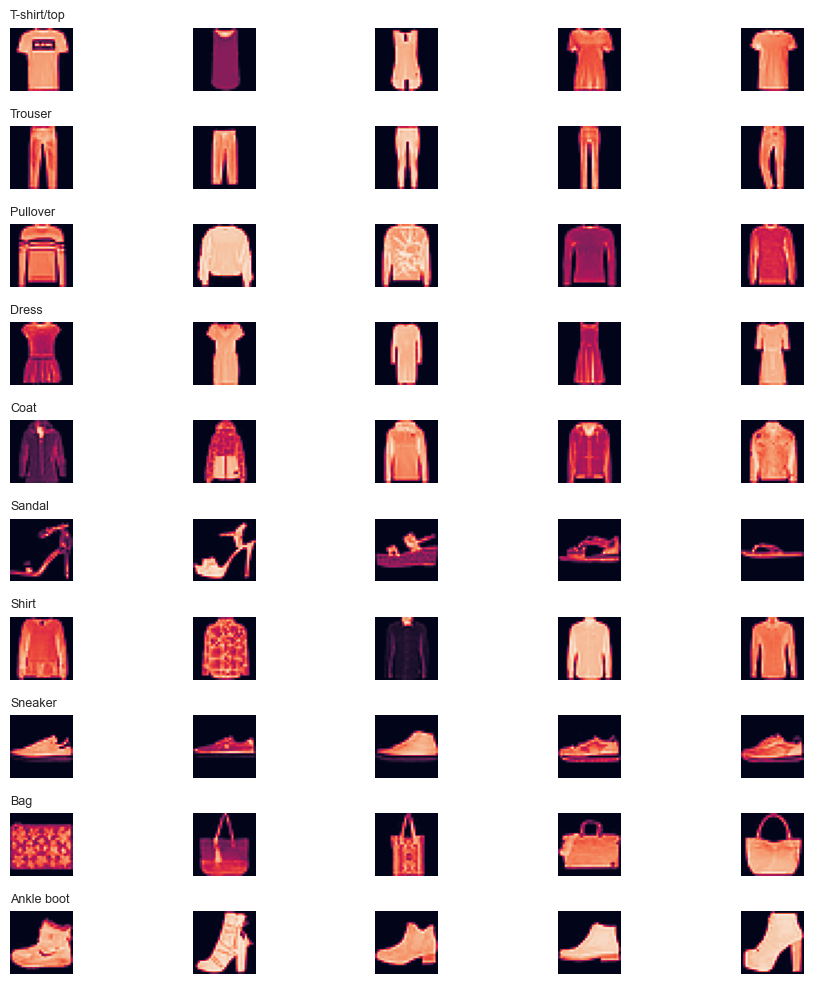

X_train min: 0, X_train max: 255


In [308]:
fig, axes = plt.subplots(10,5, figsize=(10,10))
for class_id in range(10):
    class_image = np.where(Y_train == class_id)[0][:5]
    for image_id, data_id in enumerate(class_image):
        ax = axes[class_id, image_id]
        ax.imshow(X_train[data_id])
        ax.axis("off")
        if image_id ==0:
            ax.set_title(label_names[class_id], loc = "left", fontsize=9)
plt.tight_layout()    
plt.show()
print(f"X_train min: {X_train.min()}, X_train max: {X_train.max()}")

---
### Step 3: Data preprocessing

This step is essential for preparing this image data in a format that is suitable for ML algorithms. 

### <span style="color:chocolate">Exercise 3:</span> Feature preprocessing (5 points)

In the previous lab, the input data had just a few features. Here, we treat **every pixel value as a separate feature**, so each input example has 28x28 (784) features!

In this exercise, you'll perform the following tasks:

1. Normalize the pixel values in both X_train and X_test data so they range between 0 and 1;
2. For each image in X_train and X_test, flatten the 2-D 28x28 pixel array to a 1-D array of size 784. Hint: use the <span style="color:chocolate">reshape()</span> method available in NumPy. Note that by doing so you will overwrite the original arrays;
3. Pint the shape of X_train and X_test arrays.

In [309]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler(feature_range=(0,1))
X_train = min_max_scaler.fit_transform(X_train.reshape(60000, 784))
X_test = min_max_scaler.fit_transform(X_test.reshape(10000,784))

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


### <span style="color:chocolate">Exercise 4:</span> Label preprocessing (5 points)

This assignment involves binary classification. Specifically, the objective is to predict whether an image belongs to the sneaker class (class 7) or not.

Therefore, write code so that for each example in (Y_train, Y_test), the outcome variable is represented as follows: 
* $y=1$, for sneaker class (positive examples), and
* $y=0$, for non-sneaker class (negative examples).

Note: To avoid "ValueError: assignment destination is read-only", first create a copy of the (Y_train, Y_test) data and call the resulting arrays (Y_train, Y_test). Then overwrite the (Y_train, Y_test) arrays to create binary outcomes.

In [310]:
# Make copies of the original dataset for binary classification task.
Y_train = np.copy(Y_train)
Y_test = np.copy(Y_test)

Y_train = np.where(Y_train == 7, 1, 0)
Y_test = np.where(Y_test == 7, 1, 0)

### <span style="color:chocolate">Exercise 5:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Retain 20% from the training data for validation purposes. Set random state to 1234. All the other arguments of the method are set to default values. Name the resulting dataframes as follows: X_train_mini, X_val, Y_train_mini, Y_val.
2. Print the shape of each array.

In [311]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(X_train, Y_train, random_state=1234 )
print(f"Shape X_train_mini: {X_train_mini.shape}")
print(f"Shape X_val: {X_val.shape}")
print(f"Shape Y_train_mini: {Y_train_mini.shape}")
print(f"Shape Y_val: {Y_val.shape}")

Shape X_train_mini: (45000, 784)
Shape X_val: (15000, 784)
Shape Y_train_mini: (45000,)
Shape Y_val: (15000,)


### <span style="color:chocolate">Exercise 6:</span> Data shuffling (10 points)

Since you'll be using Batch Gradient Descent (BGD) for training, it is important that **each batch is a random sample of the data** so that the gradient computed is representative. 

1. Use integer array indexing to re-order (X_train_mini, Y_train_mini) using a list of shuffled indices. In doing so, you will overwrite the arrays.

In [312]:
np.random.seed(0)
indices_x = list(range(len(X_train_mini)))
indices_y = list(range(len(Y_train_mini)))

shuffled_indices_x = np.random.permutation(indices_x)
shuffled_indices_y = np.random.permutation(indices_y)

X_train_mini = X_train_mini[shuffled_indices_x]
Y_train_mini = Y_train_mini[shuffled_indices_y]

---
### Step 4: Exploratory Data Analysis (EDA) - cont'd

Before delving into model training, let's further explore the raw feature values by comparing sneaker and non-sneaker training images.

### <span style="color:chocolate">Exercise 7:</span> Pixel distributions (10 points)

1. Identify all sneaker images in X_train_mini and calculate the mean pixel value for each sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all sneaker images.
2. Identify all non-sneaker images in X_train_mini and calculate the mean pixel value for each non-sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all non-sneaker images.
3. Based on the histogram results, assess whether there is any evidence suggesting that pixel values can be utilized to distinguish between sneaker and non-sneaker images. Justify your response.

Notes: Make sure to provide a descriptive title and axis labels for each histogran. Make sure you utilize Y_train_mini to locate the sneaker and non-sneaker class.

Mean sneaker images: 0.2868237116052856
Mean non-sneaker images: 0.28576573912052877
Based on histogram results, the frequency of pixel values near 0 is much higher in non-sneaker 
      images. But I don't think this is very useful because the distribution of sneaker pixels looks 
       somewhat uniform to me, which would make it hard for our model to find a pattern for  
       categorization. It looks like the dataset is really imbalanced- non-sneaker images have 
       lower pixel counts more frequently.


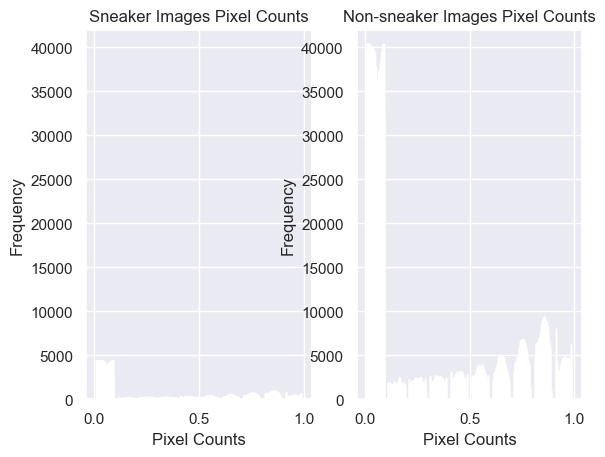

In [313]:
sneaker_images = X_train_mini[Y_train_mini==1]
mean_sneaker_images = np.mean(sneaker_images)
non_sneaker_images = X_train_mini[Y_train_mini == 0]
mean_non_sneaker_images = np.mean(non_sneaker_images)

print(f"Mean sneaker images: {mean_sneaker_images}")
print(f"Mean non-sneaker images: {mean_non_sneaker_images}")
print("Based on histogram results, the frequency of pixel values near 0 is much higher in non-sneaker \n\
      images. But I don't think this is very useful because the distribution of sneaker pixels looks \n \
      somewhat uniform to me, which would make it hard for our model to find a pattern for  \n \
      categorization. It looks like the dataset is really imbalanced- non-sneaker images have \n \
      lower pixel counts more frequently.")

fig, axes = plt.subplots(1,2)
axes[0].hist(sneaker_images)
axes[0].set_title("Sneaker Images Pixel Counts")
axes[0].set_xlabel("Pixel Counts")
axes[0].set_ylabel("Frequency")
axes[0].set_ylim(0,42000)
axes[1].hist(non_sneaker_images)
axes[1].set_title("Non-sneaker Images Pixel Counts")
axes[1].set_xlabel("Pixel Counts")
axes[1].set_ylabel("Frequency")
axes[1].set_ylim(0,42000)

plt.show()

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 8:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

With this information in mind:

1. What is the number of sneaker images in Y_train_mini? Print out your answer.
2. What is the number of non-sneaker images in Y_train_mini? Print out your answer.
3. What is the majority class in Y_train_mini? Print out your answer.
4. What is the accuracy of a majority class classifier for Y_train_mini? Print out your answer.
5. Implement a function that computes the Log Loss (binary cross-entropy) metric and use it to evaluate this baseline on both the mini train (Y_train_mini) and validation (Y_val) data. Use 0.1 as the predicted probability for your baseline (reflecting what we know about the original distribution of classes in the mini training data). Hint: for additional help, see the file ``04 Logistic Regression with Tensorflow_helper.ipynb``; You should use **np.log()** when implementing the log loss function.

In [314]:
print(f"Number sneaker images Y_train_mini: {sum(Y_train_mini==1)}")
print(f"Number non-sneaker images Y_train_mini: {sum(Y_train_mini==0)}")
print("Majority class in Y_train_mini is non_sneakers, or 0.")
print(f"Accuracy of majority class calissfier Y_train_mini: {sum(Y_train_mini==0)/len(Y_train_mini)}")


def log_loss(dataset):
    return -1/(len(dataset)) * sum(dataset * np.log(0.1) + (1-dataset)*np.log(1-0.1))

print(f"Y_train_mini log loss: {log_loss(Y_train_mini)}")
print(f"Y_val log loss: {log_loss(Y_val)}")

Number sneaker images Y_train_mini: 4504
Number non-sneaker images Y_train_mini: 40496
Majority class in Y_train_mini is non_sneakers, or 0.
Accuracy of majority class calissfier Y_train_mini: 0.8999111111111111
Y_train_mini log loss: 0.325278282242626
Y_val log loss: 0.32449704683754577


### <span style="color:chocolate">Exercise 9:</span> Improvement over Baseline with TensorFlow (10 points)

Let's use TensorFlow to train a binary logistic regression model much like you did in the previous assignment. The goal here is to build a ML model to improve over the baseline classifier.

1. Fill in the <span style="color:green">NotImplemented</span> parts of the build_model() function below by following the instructions provided as comments. Hint: the activation function, the loss, and the evaluation metric are different compared to the linear regression model;
2. Build and compile a model using the build_model() function and the (X_train_mini, Y_train_mini) data. Set learning_rate = 0.0001. Call the resulting object *model_tf*.
3. Train *model_tf* using the (X_train_mini, Y_train_mini) data. Set num_epochs = 5 and batch_size=32. Pass the (X_val, Y_val) data for validation. Hint: see the documentation behind the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method.
4. Generate a (1,2) plot (for the mini training and validation data). In the subplot at position (1, 1), display the loss values on the y-axis and the epoch number on the x-axis. In the subplot at position (1, 2), display the accuracy values on the y-axis and the epoch number on the x-axis. Hint: check what the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns.

In [315]:
def build_model(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=[num_features],  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='sigmoid',
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))

  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
  return model

/Users/LeahFinger/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


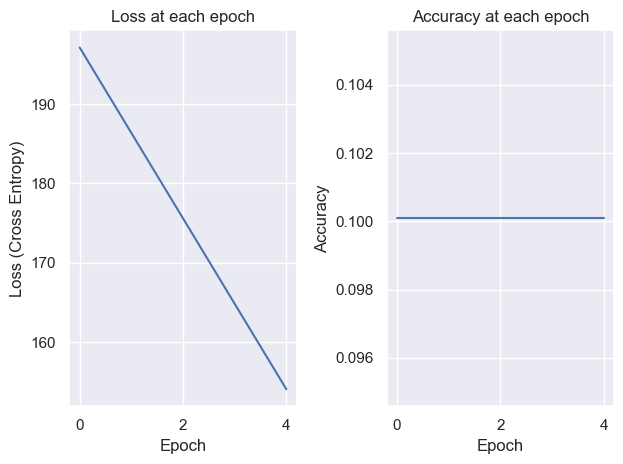

In [316]:
tf.random.set_seed(0)
# 2. Build and compile model
model_tf = build_model(X_train_mini.shape[1], 0.0001)

# 3. Fit the model
history = model_tf.fit(
  x = X_train_mini,
  y = Y_train_mini,
  epochs=5,
  batch_size=32,
  validation_data=(X_val,Y_val),
  verbose=0)

# 4. Generate (1,2) plot
loss = history.history['loss']
epoch = history.epoch
accuracy = history.history['accuracy']
fig, axes = plt.subplots(1,2)
axes[0].plot(epoch,loss)
axes[0].set_title("Loss at each epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (Cross Entropy)")
axes[1].plot(epoch, accuracy)
axes[1].set_title("Accuracy at each epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning is a crucial step in optimizing ML models. It involves systematically adjusting hyperparameters such as learning rate, number of epochs, and optimizer to find the model configuration that leads to the best generalization performance.

This tuning process is typically conducted by monitoring the model's performance on the validation vs. training set. It's important to note that using the test set for hyperparameter tuning can compromise the integrity of the evaluation process by violating the assumption of "blindness" of the test data.

### <span style="color:chocolate">Exercise 10:</span> Hyperparameter tuning (10 points)

1. Fine-tune the **learning rate** and **number of epochs** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Generate a (1, 2) subplot to visualize the training and validation loss on the left, and training and validation accuracy on the right, across all epochs. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). If you decide to work with the Keras Tuner, define a new model building function named <span style="color:chocolate">build_model_tuner()</span>.

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (including the bias term);
3. The final-epoch loss on both the mini training and validation datasets;
4. The difference between the final-epoch training and validation losses;
5. Compare the final-epoch training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Please note that we will consider 'optimal model configuration' any last-epoch training and validation loss that is below 0.08.

Reloading Tuner from my_dir/intro_to_kt_2/tuner0.json


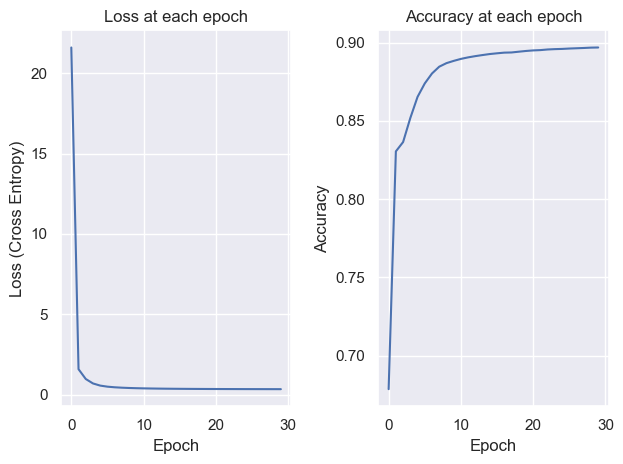

 First 5 feature coefficients: [[0.98451835]
 [0.97820204]
 [0.96962184]
 [0.87655085]
 [0.78176343]], Bias term: [-2.3183577]
 Loss at final epoch training dataset: 0.3338315784931183
 Loss at final epoch validation dataset: 0.3435589373111725
 Diff training val loss: -0.0097273588180542
The tensorflow model is not really an improvement over the baseline model. TF model loss is 
       0.3338 and baseline model loss is 0.3252 at final epoch. TF model loss is basically the same 
       as baseline model, both are not great at predicting shoes. We also see accuracy for TF 
       model at last epoch is just below 0.9 which is similar to baseline model.


In [317]:
import keras_tuner as kt

def build_model_tuner(hp):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=[X_train_mini.shape[1]],  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='sigmoid',
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))
  # Keras Tuner chooses learning rate
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
  return model

tuner = kt.Hyperband(build_model_tuner,
                     objective='val_loss',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt_2')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train_mini, Y_train_mini, epochs=50, validation_data=(X_val, Y_val),
              callbacks=[stop_early])

best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

model_tuner = tuner.hypermodel.build(best_hps)

# Fit the model with optimal hyperparameters
history_tuner = model_tuner.fit(
      x = X_train_mini,
      y = Y_train_mini,
      epochs=30,
      validation_data=(X_val, Y_val), 
      batch_size=32, # standard for logistic regression
      verbose=0) # silence the output

# Generate (1,2) plot
loss = history_tuner.history['loss']
epoch = history_tuner.epoch
accuracy = history_tuner.history['accuracy']
fig, axes = plt.subplots(1,2)
axes[0].plot(epoch,loss)
axes[0].set_title("Loss at each epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (Cross Entropy)")
axes[1].plot(epoch, accuracy)
axes[1].set_title("Accuracy at each epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

w, b = model_tuner.layers[0].get_weights()

print(f" First 5 feature coefficients: {w[:5]}, Bias term: {b[:5]}")
print(f" Loss at final epoch training dataset: {history_tuner.history["loss"][-1]}") 
print(f" Loss at final epoch validation dataset: {history_tuner.history["val_loss"][-1]}")
print(f" Diff training val loss: {history_tuner.history["loss"][-1] - history_tuner.history["val_loss"][-1]}")
print(f"The tensorflow model is not really an improvement over the baseline model. TF model loss is \n \
      0.3338 and baseline model loss is 0.3252 at final epoch. TF model loss is basically the same \n \
      as baseline model, both are not great at predicting shoes. We also see accuracy for TF \n \
      model at last epoch is just below 0.9 which is similar to baseline model.")

---
### Step 6: Evaluation and Generalization


Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

### <span style="color:chocolate">Exercise 11:</span> Computing accuracy (10 points)

1. Calculate aggregate accuracy on both mini train and test datasets using a probability threshold of 0.5. Hint: You can utilize the <span style="color:chocolate">model.evaluate()</span> method provided by tf.keras. Note: Aggregate accuracy measures the overall correctness of the model across all classes in the dataset;

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations for training vs. test datasets.

In [318]:
print("Default probability threshold is 0.5 in keras.")
loss_train, accuracy_train = model_tuner.evaluate(X_train_mini, Y_train_mini, verbose=0)
print(f"Accuracy training data: {accuracy_train}")
loss_test, accuracy_test = model_tuner.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy test data: {accuracy_test}")
print("The model where I tuned hyperparamters using the keras tuner does demonstrate strong \n \
      aggregate generaliation capabilities. Difference in accuracy across training and test data \n \
      is only about 0.002. Though the accuracy is not much better than my \n \
      baseline model, it is very consistent across my training and test dataset which means \n \
      the model does a good job of predicting unseen data in that it's accuracy is consistent.")

Default probability threshold is 0.5 in keras.
Accuracy training data: 0.8966222405433655
Accuracy test data: 0.894599974155426
The model where I tuned hyperparamters using the keras tuner does demonstrate strong 
       aggregate generaliation capabilities. Difference in accuracy across training and test data 
       is only about 0.002. Though the accuracy is not much better than my 
       baseline model, it is very consistent across my training and test dataset which means 
       the model does a good job of predicting unseen data in that it's accuracy is consistent.


### <span style="color:chocolate">Exercise 12:</span> Fairness evaluation (10 points)

1. Generate and visualize the confusion matrix on the test dataset using a probability threshold of 0.5. Additionally, print the True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN). Hint: you can utilize the <span style="color:chocolate">model.predict()</span> method available in tf.keras, and then the <span style="color:chocolate">confusion_matrix()</span>, <span style="color:chocolate">ConfusionMatrixDisplay()</span> methods available in sklearn.metrics;

2. Compute subgroup accuracy, separately for the sneaker and non-sneaker classes, on the test dataset using a probability threshold of 0.5. Reflect on any observed accuracy differences (potential lack of fairness) between the two classes.

3. Does the model demonstrate strong subgroup generalization capabilities? Provide an explanation based on your accuracy observations. Hint: compare training vs. test accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step


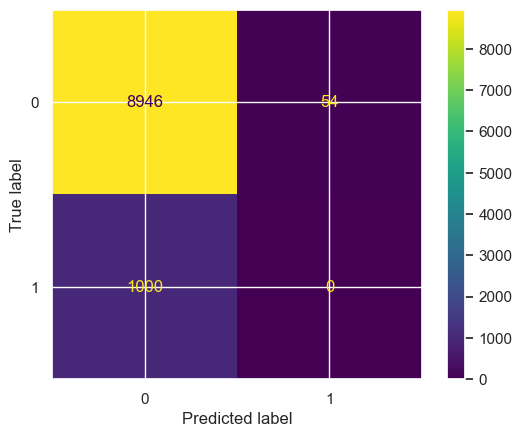

TP: 0, FN: 1000, FP: 54, TN: 8946
Default probability threshold is 0.5 in keras.
Test accuracy non-sneaker images: 0.9940000176429749
Test accuracy sneaker images: 0.0
Difference in non-sneaker vs sneaker accuracy is huge. Non-sneaker predictions are way more 
     more accurate than sneaker images- it seems our model is mostly just predicting non sneaker 
       images and is right most of the time because most images are not sneakers. The dataset is 
         highly imbalanced, biased towards non-sneaker images, so our classes are unfaily split.
Training accuracy non-sneaker images: 0.9940000176429749 
       Training accuracy sneaker images:: 0.0 
       The model does generate strong subgroup generalization capabilities in that it's accuracy 
         scores are consistent across training and test datasets. However, the model has been 
       trained to just always predict a non-sneaker image and got passable accuracy scores 
         doing that. Deploying this to predict sneaker i

In [319]:

Y_pred_probabilities = model_tuner.predict(X_test)
Y_pred = (Y_pred_probabilities >= 0.5).astype(int).flatten()
confusion_matrix_model_tuner = confusion_matrix(Y_test, Y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix_model_tuner)
cm_display.plot()
plt.show()
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel().tolist()
print(f"TP: {tp}, FN: {fn}, FP: {fp}, TN: {tn}")
print("Default probability threshold is 0.5 in keras.")
loss_ns, accuracy_non_sneaker = model_tuner.evaluate(X_test[Y_test==0], Y_test[Y_test==0], verbose=0)
loss_s, accuracy_sneaker = model_tuner.evaluate(X_test[Y_test==1], Y_test[Y_test==1], verbose=0)
print(f"Test accuracy non-sneaker images: {accuracy_non_sneaker}")
print(f"Test accuracy sneaker images: {accuracy_sneaker}")
print("Difference in non-sneaker vs sneaker accuracy is huge. Non-sneaker predictions are way more \n \
    more accurate than sneaker images- it seems our model is mostly just predicting non sneaker \n \
      images and is right most of the time because most images are not sneakers. The dataset is \n \
        highly imbalanced, biased towards non-sneaker images, so our classes are unfaily split.")
loss_ns_train, accuracy_non_sneaker_train = model_tuner.evaluate(X_test[Y_test==0], Y_test[Y_test==0], verbose=0)
loss_s_train, accuracy_sneaker_train = model_tuner.evaluate(X_test[Y_test==1], Y_test[Y_test==1], verbose=0)
print(f"Training accuracy non-sneaker images: {accuracy_non_sneaker_train} \n \
      Training accuracy sneaker images:: {accuracy_sneaker_train} \n \
      The model does generate strong subgroup generalization capabilities in that it's accuracy \n \
        scores are consistent across training and test datasets. However, the model has been \n \
      trained to just always predict a non-sneaker image and got passable accuracy scores \n \
        doing that. Deploying this to predict sneaker images would not result in much success in \n \
            identifying actual sneaker images.")

----
### <span style="color:chocolate"></span> Additional practice (not graded)

Is it possible to enhance the prediction accuracy for the sneaker class by performing the following steps?

1. Implement data balancing techniques, such as oversampling or undersampling, to equalize the representation of both classes.
2. After balancing the data, retrain the model on the balanced dataset.
3. Evaluate the model's performance, particularly focusing on the accuracy achieved for the sneaker class.


<span style="color:chocolate">Note: upload a separate notebook in Gradescope for this question.</span>